# **Task 1: Build a Simple ANN for Classification**

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


# **Load the data**

In [16]:
# Load dataset
iris = load_iris()
X = iris.data  # features
y = iris.target  # labels


In [17]:
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Target names: {iris.target_names}")

Features (X) shape: (150, 4)
Target (y) shape: (150,)
Target names: ['setosa' 'versicolor' 'virginica']


# **Preprocess the data**

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [19]:
y_encoded = to_categorical(y)


# **Split the data**

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y
)


In [21]:
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (120, 4)
Testing features shape: (30, 4)
Training target shape: (120, 3)
Testing target shape: (30, 3)


# **Build a simple ANN with one hidden layer using Keras**

In [22]:
print("\n4. Building a simple ANN with one hidden layer...")
model = Sequential([
    Dense(10, input_shape=(4,), activation='relu'),  # Hidden layer
    Dense(3, activation='softmax')                   # Output layer
])



4. Building a simple ANN with one hidden layer...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=50, batch_size=8, validation_split=0.1, verbose=0)


# **Evaluate the Model**

In [25]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Test Accuracy: 76.67%


# **Visualize Training Loss and Accuracy**

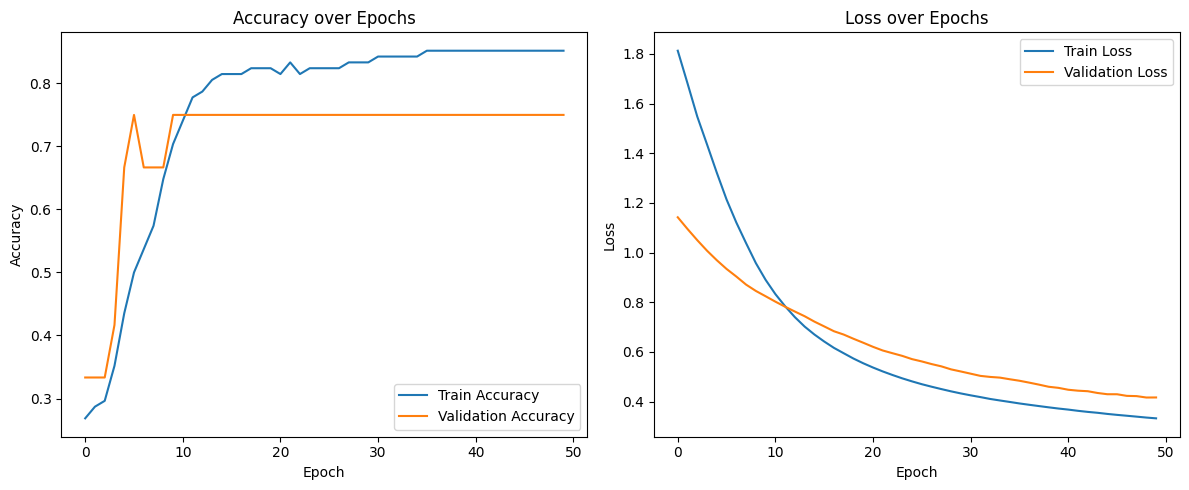

In [26]:
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# **Task 2: Experiment with Hyperparameters**

# **Import Required Libraries**

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import time
import pandas as pd


# **Load and Preprocess MNIST Dataset**

In [28]:
# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize input
x_train, x_test = x_train / 255.0, x_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# **Define Hyperparameter Grid**

In [29]:
experiments = [
    {'layers': 1, 'neurons': 64,  'lr': 0.01,  'batch_size': 32},
    {'layers': 2, 'neurons': 128, 'lr': 0.001, 'batch_size': 64},
    {'layers': 3, 'neurons': 256, 'lr': 0.0005,'batch_size': 128},
    {'layers': 2, 'neurons': 64,  'lr': 0.01,  'batch_size': 32},
    {'layers': 1, 'neurons': 128, 'lr': 0.0001,'batch_size': 64},
]


# **Model Training Loop**

In [30]:
results = []

for i, exp in enumerate(experiments):
    print(f"\nRunning experiment {i+1}: {exp}")

    model = Sequential()
    model.add(Flatten(input_shape=(28, 28)))

    for _ in range(exp['layers']):
        model.add(Dense(exp['neurons'], activation='relu'))

    model.add(Dense(10, activation='softmax'))

    optimizer = tf.keras.optimizers.Adam(learning_rate=exp['lr'])
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    start_time = time.time()
    history = model.fit(x_train, y_train,
                        epochs=5,
                        batch_size=exp['batch_size'],
                        verbose=0,
                        validation_data=(x_test, y_test))
    training_time = time.time() - start_time

    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    results.append({
        'Experiment': i+1,
        'Layers': exp['layers'],
        'Neurons': exp['neurons'],
        'LR': exp['lr'],
        'Batch Size': exp['batch_size'],
        'Accuracy': round(acc * 100, 2),
        'Loss': round(loss, 4),
        'Training Time (s)': round(training_time, 2)
    })



Running experiment 1: {'layers': 1, 'neurons': 64, 'lr': 0.01, 'batch_size': 32}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Running experiment 2: {'layers': 2, 'neurons': 128, 'lr': 0.001, 'batch_size': 64}

Running experiment 3: {'layers': 3, 'neurons': 256, 'lr': 0.0005, 'batch_size': 128}

Running experiment 4: {'layers': 2, 'neurons': 64, 'lr': 0.01, 'batch_size': 32}

Running experiment 5: {'layers': 1, 'neurons': 128, 'lr': 0.0001, 'batch_size': 64}


# **Results Table**

In [31]:
df_results = pd.DataFrame(results)
print(df_results)


   Experiment  Layers  Neurons      LR  Batch Size  Accuracy    Loss  \
0           1       1       64  0.0100          32     95.94  0.1776   
1           2       2      128  0.0010          64     97.67  0.0833   
2           3       3      256  0.0005         128     97.79  0.0699   
3           4       2       64  0.0100          32     96.00  0.1739   
4           5       1      128  0.0001          64     94.31  0.1982   

   Training Time (s)  
0              39.86  
1              27.39  
2              27.58  
3              35.80  
4              25.49  


# **Create Comparison Charts**

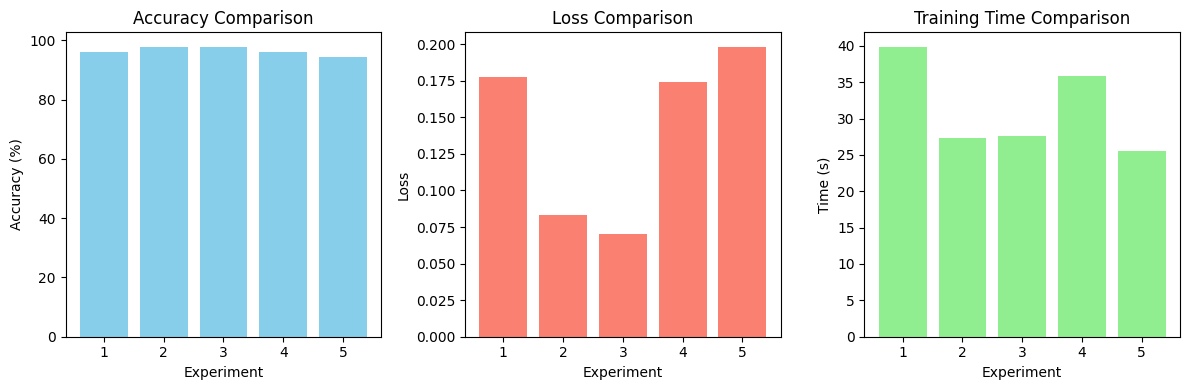

In [32]:
# Bar chart for accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.bar(df_results['Experiment'], df_results['Accuracy'], color='skyblue')
plt.title('Accuracy Comparison')
plt.xlabel('Experiment')
plt.ylabel('Accuracy (%)')

# Bar chart for loss
plt.subplot(1, 3, 2)
plt.bar(df_results['Experiment'], df_results['Loss'], color='salmon')
plt.title('Loss Comparison')
plt.xlabel('Experiment')
plt.ylabel('Loss')

# Bar chart for training time
plt.subplot(1, 3, 3)
plt.bar(df_results['Experiment'], df_results['Training Time (s)'], color='lightgreen')
plt.title('Training Time Comparison')
plt.xlabel('Experiment')
plt.ylabel('Time (s)')

plt.tight_layout()
plt.show()


# **Task 3: Build a Regression Model**

# Objective: Create an ANN for predicting house prices.

# **Import Required Libraries**

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import boston_housing


# **Load the Boston Housing Dataset**

In [34]:
# Load dataset
(x_train, y_train), (x_test, y_test) = boston_housing.load_data()


57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# **Preprocess the Data**

In [35]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


# **Build the Regression ANN Model**

In [38]:
model = Sequential([
    Dense(64, input_shape=(x_train.shape[1],), activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)  # Output layer for regression (no activation)
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **Compile and Train the Model**

In [39]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(x_train_scaled, y_train,
                    epochs=100,
                    batch_size=16,
                    validation_split=0.1,
                    verbose=0)


# **Evaluate Model Performance**

In [40]:
mse, mae = model.evaluate(x_test_scaled, y_test, verbose=0)
print(f"Test MSE: {mse:.2f}")
print(f"Test MAE: {mae:.2f}")


Test MSE: 17.46
Test MAE: 2.66


# **Predict and Visualize Actual vs. Predicted Prices**

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


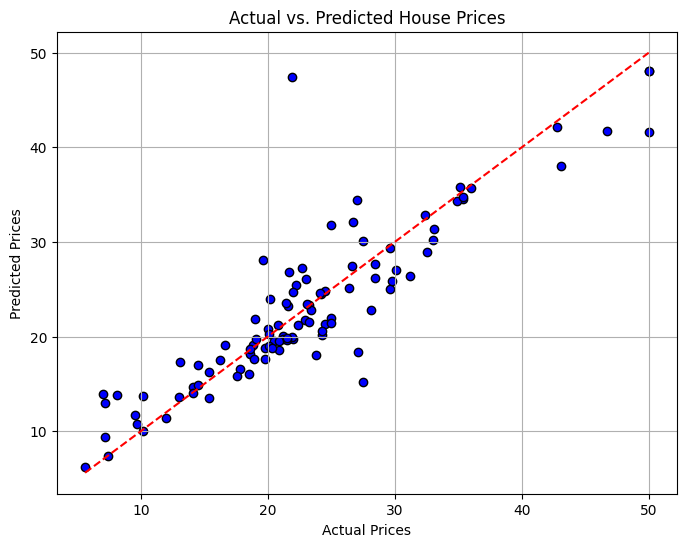

In [41]:
y_pred = model.predict(x_test_scaled).flatten()

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted House Prices")
plt.grid(True)
plt.show()


# **Task 4: Multi-Class Classification with the Fashion MNIST Dataset**

Objective: Build and evaluate an ANN for classifying images of clothing.

# **Import Required Libraries**

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split


# **Load the Fashion MNIST Dataset**

In [43]:
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# **Preprocess the Data**

In [44]:
x_train_full = x_train_full / 255.0
x_test = x_test / 255.0


# Split training into training and validation

In [45]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full
)


# One-hot encode the labels

In [46]:
y_train_cat = to_categorical(y_train, num_classes=10)
y_val_cat = to_categorical(y_val, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)


# **Build the ANN Model with Multiple Hidden Layers**



In [47]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')  # 10 output classes
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# **Compile and Train the Model**

In [48]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    x_train, y_train_cat,
    validation_data=(x_val, y_val_cat),
    epochs=15,
    batch_size=64,
    verbose=1
)


Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7634 - loss: 0.6795 - val_accuracy: 0.8655 - val_loss: 0.3775
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8610 - loss: 0.3828 - val_accuracy: 0.8778 - val_loss: 0.3411
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8741 - loss: 0.3381 - val_accuracy: 0.8695 - val_loss: 0.3531
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8837 - loss: 0.3093 - val_accuracy: 0.8725 - val_loss: 0.3408
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8926 - loss: 0.2917 - val_accuracy: 0.8872 - val_loss: 0.3063
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8938 - loss: 0.2774 - val_accuracy: 0.8903 - val_loss: 0.2995
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9007 - loss: 0.2610 - val_accuracy: 0.8922 - val_loss: 0.2900
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9049 - loss: 0.2505 - val_accurac

# **Evaluate the Model**

In [49]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Test Accuracy: 87.69%


# **Confusion Matrix and Classification Report**

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


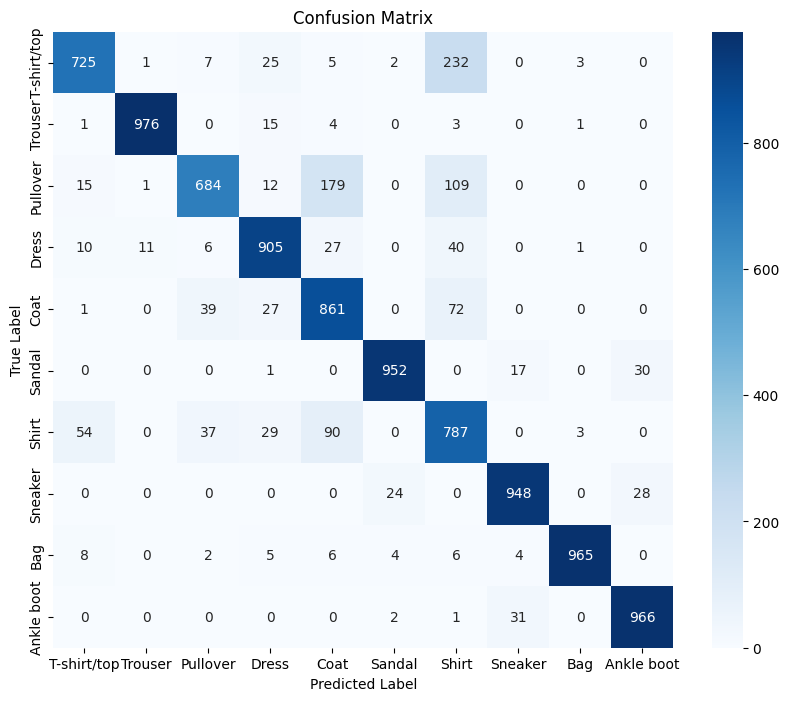

Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.89      0.72      0.80      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.88      0.68      0.77      1000
       Dress       0.89      0.91      0.90      1000
        Coat       0.73      0.86      0.79      1000
      Sandal       0.97      0.95      0.96      1000
       Shirt       0.63      0.79      0.70      1000
     Sneaker       0.95      0.95      0.95      1000
         Bag       0.99      0.96      0.98      1000
  Ankle boot       0.94      0.97      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



In [51]:
# Define label names
fashion_mnist_labels = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Predict and evaluate
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=fashion_mnist_labels,
            yticklabels=fashion_mnist_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=fashion_mnist_labels))


# **Task 5: Time Series Forecasting with LSTMs**

Objective: Predict future values in a time series using Long Short-Term Memory (LSTM)
networks.

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


# **Load and Prepare Time Series Dataset**

In [84]:
# Generate example time series data (or load your own CSV file)
dates = pd.date_range(start='2020-01-01', periods=500, freq='D')
data = np.sin(np.linspace(0, 50, 500)) + np.random.normal(0, 0.2, 500)
df = pd.DataFrame({'Date': dates, 'Value': data})
df.set_index('Date', inplace=True)


# **Normalize and Create LSTM Sequences**

In [85]:
# Normalize
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Convert to sequences
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i])
        y.append(data[i])
    return np.array(X), np.array(y)

window_size = 30
X, y = create_sequences(scaled_data, window_size)

# Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


# **Build the LSTM Model**

In [88]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(50, activation='relu', input_shape=(window_size, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# **Train the Model**

In [89]:
history = model.fit(X_train, y_train, epochs=20, batch_size=16, validation_split=0.1, verbose=1)


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.2303 - val_loss: 0.1372
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0717 - val_loss: 0.0470
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0347 - val_loss: 0.0269
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0148 - val_loss: 0.0216
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0142 - val_loss: 0.0107
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0077 - val_loss: 0.0089
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0081 - val_loss: 0.0086
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0074 - val_loss: 0.0086
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0065 - val_loss: 0.0081
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0077 - val_loss: 0.0081
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0056 - val_loss: 0.0092
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0

# **Evaluate the Model (RMSE)**

In [90]:
# Predict
y_pred = model.predict(X_test)

# Inverse scale
y_test_rescaled = scaler.inverse_transform(y_test)
y_pred_rescaled = scaler.inverse_transform(y_pred)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
print(f"Test RMSE: {rmse:.3f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Test RMSE: 0.231


# **Visualize Actual vs. Predicted**

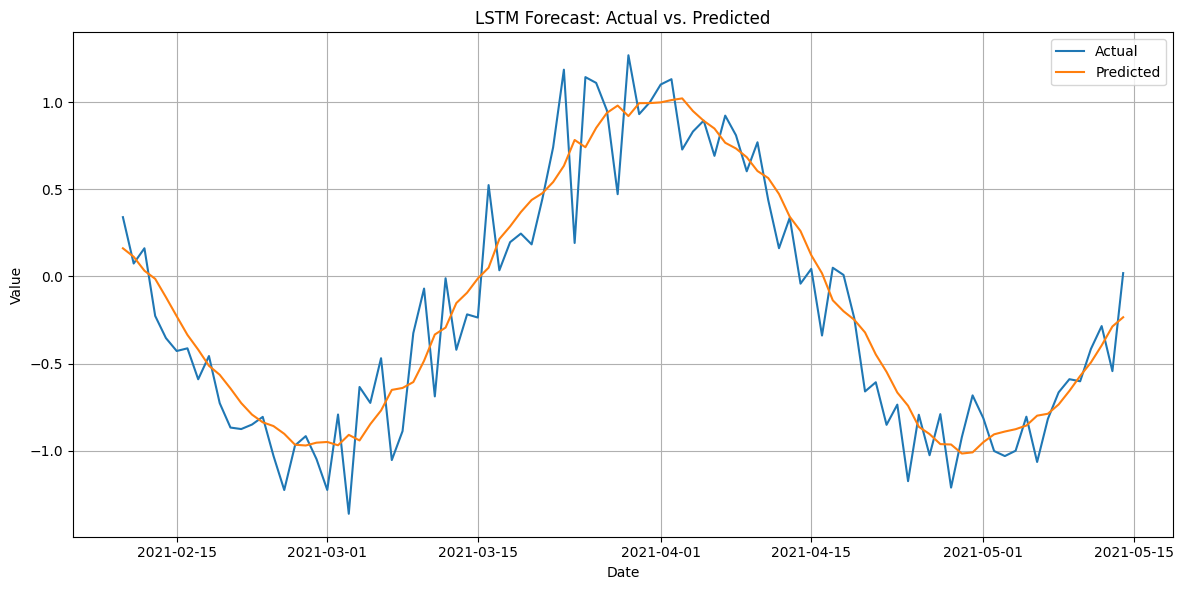

In [91]:
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_test):], y_test_rescaled, label='Actual')
plt.plot(df.index[-len(y_test):], y_pred_rescaled, label='Predicted')
plt.title("LSTM Forecast: Actual vs. Predicted")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# **Task 6: Ensemble Learning with ANNs**
Objective: Improve model performance through ensemble methods.

# **Import Required Libraries**

In [102]:
pip install scikeras


In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier

from sklearn.ensemble import BaggingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

# **Load and Preprocess the Dataset**

In [94]:
# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


# **Define Base ANN Model Function**

In [95]:
def create_model(units=16):
    model = Sequential()
    model.add(Dense(units, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dense(units, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


# **Train Individual ANN Models**

In [96]:
# Create individual models with different architectures
models = [
    KerasClassifier(build_fn=lambda: create_model(8), epochs=50, batch_size=16, verbose=0),
    KerasClassifier(build_fn=lambda: create_model(16), epochs=50, batch_size=16, verbose=0),
    KerasClassifier(build_fn=lambda: create_model(32), epochs=50, batch_size=16, verbose=0)
]

# Fit and evaluate each individual model
individual_scores = []
for i, model in enumerate(models):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    individual_scores.append(acc)
    print(f"Model {i+1} Accuracy: {acc:.4f}")


/usr/local/lib/python3.11/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 1 Accuracy: 0.9825


/usr/local/lib/python3.11/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 2 Accuracy: 0.9561


/usr/local/lib/python3.11/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 3 Accuracy: 0.9649


# **Bagging Ensemble**

In [97]:
bagging_model = BaggingClassifier(
    estimator=KerasClassifier(build_fn=lambda: create_model(16), epochs=50, batch_size=16, verbose=0),
    n_estimators=5,
    random_state=42
)
bagging_model.fit(X_train, y_train)
bagging_preds = bagging_model.predict(X_test)
bagging_acc = accuracy_score(y_test, bagging_preds)
print(f"\nBagging Ensemble Accuracy: {bagging_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using 


Bagging Ensemble Accuracy: 0.9561


# **Stacking Ensemble**

In [98]:
from scikeras.wrappers import KerasClassifier


In [99]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [
    ('ann1', KerasClassifier(model=create_model, units=8, epochs=50, batch_size=16, verbose=0)),
    ('ann2', KerasClassifier(model=create_model, units=16, epochs=50, batch_size=16, verbose=0)),
    ('ann3', KerasClassifier(model=create_model, units=32, epochs=50, batch_size=16, verbose=0)),
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    passthrough=True,
    cv=5
)


In [104]:
import numpy as np
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from scikeras.wrappers import KerasClassifier

# Load MNIST data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize and reshape
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

# Use only small data for faster stacking example
x_train_small, _, y_train_small, _ = train_test_split(x_train, y_train, train_size=5000, stratify=y_train)

# Build model function
def create_model(neurons=32):
    model = Sequential()
    model.add(Dense(neurons, activation='relu', input_shape=(784,)))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Define base estimators using scikeras
estimators = [
    ('model1', KerasClassifier(model=create_model, model__neurons=16, epochs=5, batch_size=64, verbose=0)),
    ('model2', KerasClassifier(model=create_model, model__neurons=32, epochs=5, batch_size=64, verbose=0))
]

# Final estimator
final_estimator = LogisticRegression()

# Create StackingClassifier
stack_model = StackingClassifier(estimators=estimators, final_estimator=final_estimator, passthrough=False)

# Fit
stack_model.fit(x_train_small, y_train_small)

# Predict
preds = stack_model.predict(x_test)

# Evaluate
acc = accuracy_score(y_test, preds)
print(f"\nStacking Ensemble Accuracy: {acc:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [100]:
stack_model.fit(X_train, y_train)
stack_preds = stack_model.predict(X_test)

from sklearn.metrics import accuracy_score
stack_acc = accuracy_score(y_test, stack_preds)
print(f"\nStacking Ensemble Accuracy: {stack_acc:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


AttributeError: 'super' object has no attribute '__sklearn_tags__'

# Visualize Results



In [82]:
labels = ['Model 1 (8 units)', 'Model 2 (16 units)', 'Model 3 (32 units)', 'Bagging', 'Stacking']
accuracies = individual_scores + [bagging_acc, stack_acc]

plt.figure(figsize=(10, 6))
plt.bar(labels, accuracies, color=['skyblue', 'orange', 'lightgreen', 'purple', 'red'])
plt.ylim(0.9, 1.0)
plt.ylabel("Accuracy")
plt.title("Individual vs Ensemble Model Accuracies")
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


NameError: name 'stack_acc' is not defined